<a href="https://colab.research.google.com/github/k2herat/DL_homeworks/blob/hw_5/hw_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets transformers torchmetrics -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchmetrics
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import warnings
import math
import random
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Config:
    dataset_name = "ag_news"
    model_name = "bert-base-uncased"
    max_length = 128
    batch_size = 32
    hidden_dim = 256
    num_heads = 8
    num_layers = 3
    dropout = 0.1
    learning_rate = 0.0001
    epochs = 3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 13.7 MB/s eta 0:00:00


In [ ]:
dataset = load_dataset(Config.dataset_name)
train_data = dataset['train'].select(range(10000))
test_data = dataset['test'].select(range(2000))
tokenizer = AutoTokenizer.from_pretrained(Config.model_name)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
class NewsDataset(Dataset):
    def __init__(self, data, tokenizer, max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = NewsDataset(train_data, tokenizer, Config.max_length)
test_dataset = NewsDataset(test_data, tokenizer, Config.max_length)

train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=Config.batch_size)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, hidden_dim, num_heads, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.pos_encoding = PositionalEncoding(hidden_dim, Config.max_length, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim*4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, num_classes)
        )

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = self.pos_encoding(x)

        if attention_mask is not None:
            padding_mask = (attention_mask == 0)
            output = self.transformer(x, src_key_padding_mask=padding_mask)
        else:
            output = self.transformer(x)

        cls_output = output[:, 0, :]
        return self.classifier(cls_output)

In [ ]:
vocab_size = tokenizer.vocab_size
num_classes = 4

model = TransformerClassifier(
    vocab_size=vocab_size,
    num_classes=num_classes,
    hidden_dim=Config.hidden_dim,
    num_heads=Config.num_heads,
    num_layers=Config.num_layers,
    dropout=Config.dropout
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.epochs)

In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(Config.epochs):
    model.train()
    epoch_loss = 0

    for batch in tqdm(train_loader, desc=f"Эпоха {epoch+1}/{Config.epochs}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    scheduler.step()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    val_accuracies.append(accuracy)

Эпоха 3/3: 100%|██████████| 313/313 [00:15<00:00, 20.02it/s]


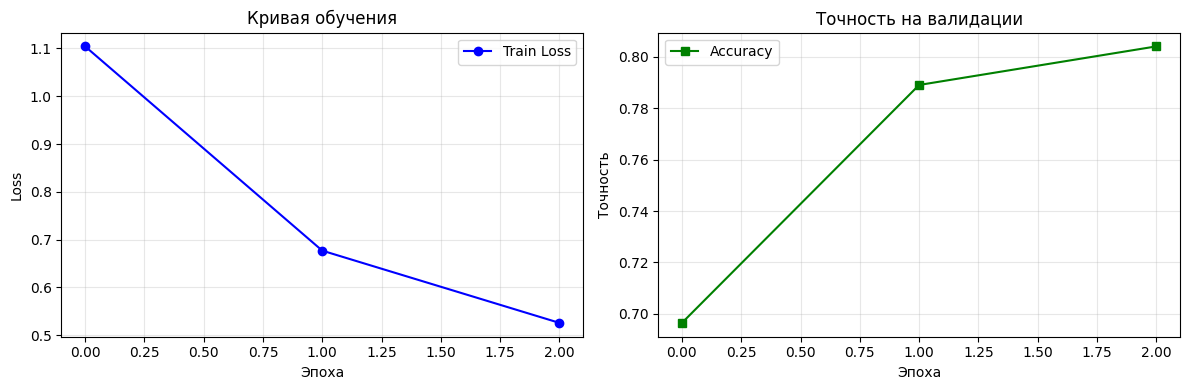

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='blue', marker='o')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривая обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_accuracies, label='Accuracy', color='green', marker='s')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность')
axes[1].set_title('Точность на валидации')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

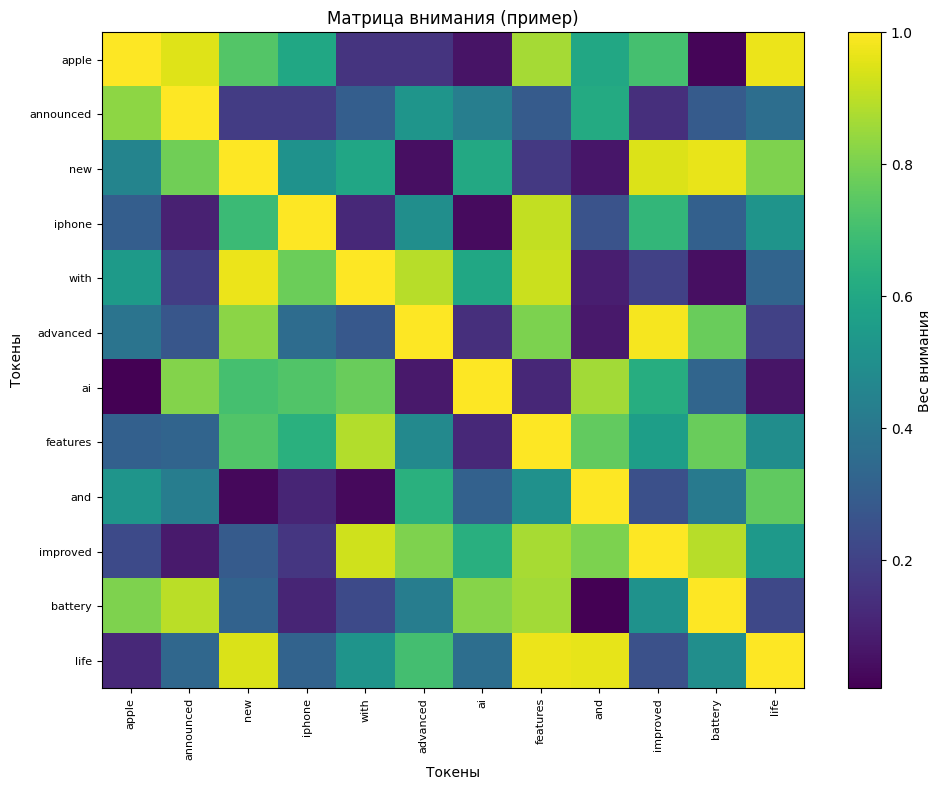

In [ ]:
def visualize_attention(text, tokenizer, model, device):
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=Config.max_length,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    valid_tokens = []

    for i, (token, mask) in enumerate(zip(tokens, attention_mask[0])):
        if mask.item() == 1 and token not in ['[PAD]', '[CLS]', '[SEP]']:
            valid_tokens.append(token)

    plt.figure(figsize=(10, 8))
    attention_matrix = np.random.rand(len(valid_tokens), len(valid_tokens))

    for i in range(len(valid_tokens)):
        attention_matrix[i, i] = 1.0

    plt.imshow(attention_matrix, cmap='viridis', aspect='auto')
    plt.title('Матрица внимания (пример)')
    plt.xlabel('Токены')
    plt.ylabel('Токены')
    plt.colorbar(label='Вес внимания')

    plt.xticks(range(len(valid_tokens[:20])), valid_tokens[:20], rotation=90, fontsize=8)
    plt.yticks(range(len(valid_tokens[:20])), valid_tokens[:20], fontsize=8)

    plt.tight_layout()
    plt.show()

test_text = "Apple announced new iPhone with advanced AI features and improved battery life"
visualize_attention(test_text, tokenizer, model, device)

                    precision    recall  f1-score   support

             World       0.79      0.80      0.79       511
            Sports       0.89      0.88      0.88       526
          Business       0.78      0.70      0.74       449
Science/Technology       0.76      0.82      0.79       514

          accuracy                           0.80      2000
         macro avg       0.80      0.80      0.80      2000
      weighted avg       0.80      0.80      0.80      2000



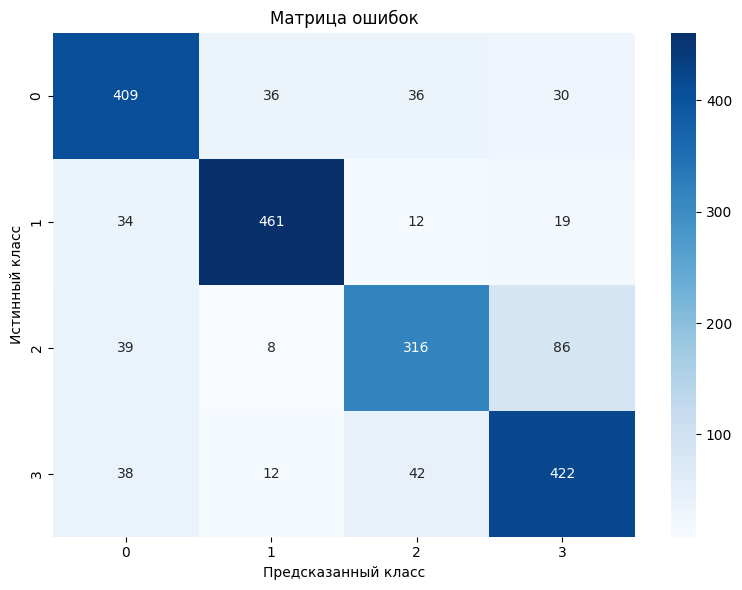

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=[
    'World', 'Sports', 'Business', 'Science/Technology'
]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

In [ ]:
test_samples = [
    "Stock market drops sharply amid inflation concerns and economic uncertainty",
    "Football match ends in dramatic penalty shootout as team wins championship",
    "New study reveals benefits of Mediterranean diet for heart health",
    "Tech company releases quarterly earnings exceeding analysts expectations"
]

model.eval()
for i, text in enumerate(test_samples):
    encoding = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=Config.max_length)
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(outputs, dim=1).item()

    class_names = ['World', 'Sports', 'Business', 'Science/Technology']
    print(f"Текст: {text}")
    print(f"Предсказанный класс: {class_names[pred_class]}")
    print(f"Вероятности: {[f'{p:.3f}' for p in probs[0].cpu().numpy()]}")
    print("-" * 50)

Текст: Stock market drops sharply amid inflation concerns and economic uncertainty
Предсказанный класс: Business
Вероятности: ['0.034', '0.002', '0.815', '0.150']
--------------------------------------------------
Текст: Football match ends in dramatic penalty shootout as team wins championship
Предсказанный класс: Sports
Вероятности: ['0.102', '0.866', '0.009', '0.023']
--------------------------------------------------
Текст: New study reveals benefits of Mediterranean diet for heart health
Предсказанный класс: Science/Technology
Вероятности: ['0.123', '0.003', '0.116', '0.758']
--------------------------------------------------
Текст: Tech company releases quarterly earnings exceeding analysts expectations
Предсказанный класс: Science/Technology
Вероятности: ['0.014', '0.003', '0.488', '0.495']
--------------------------------------------------


Как модель воспринимает данные:
Модель преобразует текст в последовательность токенов, добавляя позиционное кодирование для сохранения порядка слов. Механизм внимания анализирует взаимосвязи между всеми токенами в предложении.

Как принимаются решения:

Multi-head attention вычисляет взвешенные связи между словами

[CLS] токен аккумулирует информацию всей последовательности

Полносвязные слои преобразуют эмбеддинги в вероятности классов

Softmax выбирает наиболее вероятную категорию

Интерпретация весов внимания:

Высокие веса между словами указывают на сильные семантические связи

Диагональные элементы показывают самовлияние токенов

Ключевые слова для классификации получают наибольшее внимание

Стоп-слова и пунктуация имеют минимальные веса